#### [ CNN Fashion MNIST MODEL]

[1] 모듈 로딩 및 데이터 준비<hr>

In [48]:
## 모듈 로딩
import torch                                        ## Tensor 및 기본 함수들 관련 모듈
import torch.nn as nn                               ## 인공신경망 관련 모듈
import torch.nn.functional as F # type: ignore
import torch.optim as optim 
from  torch.optim.lr_scheduler import ReduceLROnPlateau
from torchmetrics.classification import *

from torchvision.datasets import FashionMNIST       ## 비젼관련 내장 데이터셋 모듈
from torch.utils.data import DataLoader             ## Pytorch의 데이터셋 관련 모듈
from torchinfo import summary                       ## 모델 구조 및 정보 확인 모듈

import torchvision.transforms as transforms         ## 비젼관련 이미지 증강/변환 관련 모듈

import matplotlib.pyplot as plt                     ## 이미지 시각화 


In [49]:
## 이미지 관련 준비
IMG_ROOT = '../_image/fashion/'                         ## 이미지 데이터 저장 폴더 경로



[2] 데이터 로딩 <hr>

In [50]:
## 내장 데이터셋 로딩
trainDS=FashionMNIST(root=IMG_ROOT,
                     download=False,
                     train=True,
                     transform=transforms.ToTensor())

In [51]:
testDS=FashionMNIST(root=IMG_ROOT,
                     download=False,
                     train=False, 
                     transform=transforms.ToTensor())

In [52]:
## 데이터셋 체크
## - 타입
print(f'type         : {type(testDS)}')

## - 속성 : 클래스 정보
print(f'classes      : {testDS.classes}')
print(f'class_to_idx : {testDS.class_to_idx}')

type         : <class 'torchvision.datasets.mnist.FashionMNIST'>
classes      : ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
class_to_idx : {'T-shirt/top': 0, 'Trouser': 1, 'Pullover': 2, 'Dress': 3, 'Coat': 4, 'Sandal': 5, 'Shirt': 6, 'Sneaker': 7, 'Bag': 8, 'Ankle boot': 9}


In [53]:
## - 속성 : 데이터와 타겟
print(f'targets      : {testDS.targets} {len(trainDS.classes)}')
print(f'data         : {testDS.data.shape}')


targets      : tensor([9, 2, 1,  ..., 8, 1, 5]) 10
data         : torch.Size([10000, 28, 28])


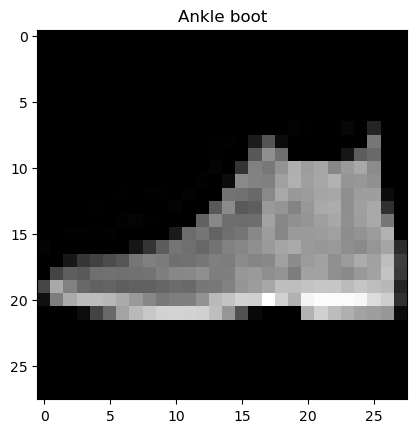

In [54]:
## 이미지 데이터와 타겟 확인
idx_to_classes ={v:k for k, v in testDS.class_to_idx.items()}

plt.imshow(testDS.data[0], cmap='gray')
plt.title(idx_to_classes[testDS.targets[0].item()])
plt.show()

[3] 모델 정의 및 설계 <hr>

In [55]:
## DNN MODEL -----------------------------------------------------------------------
## 클래스이름 : FashionDNN
## 부모클래스 : nn.Module
## 모델구현법 : 지도학습 + 다중 분류 
## 모델층 구성  입력피쳐/신호     출력/퍼셉트론수    활성화함수
## 입  력  층       784             512             ReLu
## 은  닉  층       512             256             ReLu
## 은  닉  층       256             130             ReLu
## 출  력  층       130             10               X
## ----------------------------------84----------------------------------------------
class FashionDNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.in_layer   = nn.Flatten()
        self.hd_layer1  = nn.Linear(784, 512)
        self.drop_layer = nn.Dropout(0.25)
        self.hd_layer2  = nn.Linear(512, 256)
        self.hd_layer3  = nn.Linear(256, 130)
        self.out_layer  = nn.Linear(130, 10)
        
    ## 순방향 학습 진행 메서드 
    def forward(self, data):
        ## 3D (BS, H, W) ==> 2D (BS, H*W)
        out = self.in_layer(data)

        out =F.relu(self.hd_layer1(out))
        out = self.drop_layer(out)

        out =F.relu(self.hd_layer2(out))
        out = self.drop_layer(out)

        out =F.relu(self.hd_layer3(out))
        out = self.out_layer(out)
        
        return out

In [56]:
## 모델 구조 확인 
from models import * 

m1 = FashionDNN()
summary(m1, input_size=(100, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
FashionDNN                               [100, 10]                 --
├─Flatten: 1-1                           [100, 784]                --
├─Linear: 1-2                            [100, 512]                401,920
├─Dropout: 1-3                           [100, 512]                --
├─Linear: 1-4                            [100, 256]                131,328
├─Dropout: 1-5                           [100, 256]                --
├─Linear: 1-6                            [100, 130]                33,410
├─Linear: 1-7                            [100, 10]                 1,310
Total params: 567,968
Trainable params: 567,968
Non-trainable params: 0
Total mult-adds (M): 56.80
Input size (MB): 0.31
Forward/backward pass size (MB): 0.73
Params size (MB): 2.27
Estimated Total Size (MB): 3.31

In [57]:
## DNN모델에 이미지 테스트
testImg = trainDS.data[0:2].float()
pre=m1(testImg)
pre.argmax(axis=1), trainDS.targets[0:2]

(tensor([3, 6]), tensor([9, 0]))

[4] 학습 준비 <hr>

In [58]:
## 학습 설정
EPOCHS      = 10
BATCH_SIZE  = 100
T_ITERATION = int(trainDS.data.shape[0]/BATCH_SIZE)
V_ITERATION = int(testDS.data.shape[0]/BATCH_SIZE)

LR          = 0.001
DEVICE      = 'gpu' if torch.cuda.is_available() else 'cpu'

PAT_CNT     = 10
CLASSES     = len(trainDS.classes)

In [59]:
## 인스턴스 생성
TRAINDL     = DataLoader(trainDS, batch_size=BATCH_SIZE, shuffle=True)
TESTDL      = DataLoader(testDS,  batch_size=BATCH_SIZE, shuffle=True)

MODEL       = FashionDNN()
OPTIMIZER   = optim.Adam(MODEL.parameters(), lr=LR)
SCHEDULER   = ReduceLROnPlateau(OPTIMIZER, mode='min', patience=PAT_CNT)

LOSS_FN     = nn.CrossEntropyLoss()
SCORE_FN    = MulticlassAccuracy(num_classes=CLASSES)

-> 학습 진행 

In [82]:
# 학습함수
# - 검증함수: 테스트 또는 검증용 데이터셋 사용하는 함수
#       W,b는 업데이트 안함.
def evaluate():
    # 에포크 단위로 검증 => 검증 모드
    MODEL.eval()
    
    # W, b가 업데이트 해제
    with torch.no_grad():
        # # 방법1) 테스트용 DL 적용
        T_LOSS, T_ACC, T_PRE, T_RECALL, CNT = 0, 0, 0, 0, 0
        for feature, target in TESTDL:            
            # 검증진행
            pre_y= MODEL(feature)
            
            # 손실 계산
            loss = LOSS_FN(pre_y, target.reshape(-1))
            
            # 정확도 계산
            accuracy = MulticlassAccuracy(num_classes=10)
            prescision = MulticlassPrecision(num_classes=10)
            recall = MulticlassRecall(num_classes=10)
            f1 = MulticlassF1Score(num_classes=10)
            
            
            T_PRE += prescision(pre_y, target.reshape(-1)).item()
            T_RECALL += recall(pre_y, target.reshape(-1)).item()
            T_ACC += accuracy(pre_y, target.reshape(-1)).item()
            T_LOSS += loss.item()
            CNT += 1
            return T_LOSS/CNT, T_ACC/CNT#, T_PRE/CNT, T_RECALL/CNT
    
        # # 방법2) 전테 테스트데이터
        # # DF/SR => Tensor화
        # # 검증용 데이터셋 => 텐서화 ndarray ==> tensor변환
        # x = torch.FloatTensor(X_test.values) 
        # y = torch.LongTensor(y_test)
        
        # # 검증진행
        # pre_y= MODEL(x)
        
        # # 손실 계산
        # loss = LOSS_FN(pre_y, y.reshape(-1))

        # # 정확도 계산
        # accuracy = MulticlassAccuracy(num_classes=10)
        # acc = accuracy(pre_y, y.reshape(-1))
        
        # return loss.item(), acc.item()

In [83]:
##- 학습 함수 --------------------------------------------
##- 학습용 데이터셋으로 모델 검증
## w, b업데이트 진행행
##- -----------------------------------------------------
def training():
    # 학습 모드 설정
    MODEL.train()

    E_LOSS = 0
    E_ACC = 0
    #for i in range(ITERATION): 
    for feature, target in TRAINDL:
        # 배치 크기만큼 feature, target 로딩
        # print(feature.shape, target.shape)
                                                                            
        # 가중치 기울기 0 초기화
        OPTIMIZER.zero_grad()

        # 학습 진행
        pre_y = MODEL(feature)

        # 손실 계산
        loss = LOSS_FN(pre_y, target.reshape(-1))
        
        # 역전파 진행
        loss.backward()

        # 가중치/절편 업데이트
        OPTIMIZER.step()
        
        # 정확도 계산
        accuracy = MulticlassAccuracy(num_classes=10)
        acc = accuracy(pre_y, target.reshape(-1))
       
        E_ACC += acc.item()
        E_LOSS += loss.item()

    return E_LOSS/T_ITERATION, E_ACC/T_ITERATION

In [97]:
## 학습 관련 모듈 로딩
# from utils import * 

# 에포크 : DS 처음부터 ~ 끝까지 학습  
HIST ={'Train':[[],[]], 'Valid':[[],[]]}  

# 에포크 단위 학습/검증 진행 
for epoch in range(EPOCHS):
    # trainLoss, trainAcc = training(MODEL, TRAINDL, OPTIMIZER, LOSS_FN, SCORE_FN, T_ITERATION)
    # validLoss, validAcc = evaluate(MODEL, TESTDL, LOSS_FN, SCORE_FN, V_ITERATION)
    trainLoss, trainAcc = training()
    validLoss, validAcc = evaluate()

    HIST['Train'][0].append(trainLoss) 
    HIST['Train'][1].append(trainAcc) 
    
    HIST['Valid'][0].append(validLoss) 
    HIST['Valid'][1].append(validAcc) 

    print(f'\nEPOCH[{epoch}/{EPOCHS}]----------------')
    print(f'- TRAIN_LOSS {trainLoss:.5f}  ACC {trainAcc:.5f}')
    print(f'- VALID_LOSS {validLoss:.5f}  ACC {validAcc:.5f}')
    
    ## 모델 저장부분
    MODEL_PATH = './models/'
    MODEL_FILE = 'catdog_model.pt'

    MAX_ACC  = 0.9

    #모델 저장 기준
    # if MAX_ACC < validAcc :
    #     # torch.save(MODEL, MODEL_PATH+MODEL_FILE)
    #     torch.save(MODEL, f'{MODEL_PATH}cd_model_epoch_{epoch:02d}.pt')
    #     MAX_ACC = validAcc
        
    ## 모델 층별 가중치+ 바이어스 저장
    if MAX_ACC < validAcc :
        # torch.save(MODEL, MODEL_PATH+MODEL_FILE)
        torch.save(MODEL.state_dict(), f'{MODEL_PATH}cd_model_weights_epoch_{epoch:02d}.pt')
        MAX_ACC = validAcc 
        
        
    


EPOCH[0/10]----------------
- TRAIN_LOSS 0.23845  ACC 0.91024
- VALID_LOSS 0.30891  ACC 0.93216

EPOCH[1/10]----------------
- TRAIN_LOSS 0.23545  ACC 0.91062
- VALID_LOSS 0.29376  ACC 0.90530

EPOCH[2/10]----------------
- TRAIN_LOSS 0.23118  ACC 0.91208
- VALID_LOSS 0.35716  ACC 0.90258

EPOCH[3/10]----------------
- TRAIN_LOSS 0.22728  ACC 0.91379
- VALID_LOSS 0.25480  ACC 0.90590

EPOCH[4/10]----------------
- TRAIN_LOSS 0.22331  ACC 0.91448
- VALID_LOSS 0.23655  ACC 0.86889

EPOCH[5/10]----------------
- TRAIN_LOSS 0.21817  ACC 0.91709
- VALID_LOSS 0.53988  ACC 0.77965

EPOCH[6/10]----------------
- TRAIN_LOSS 0.21675  ACC 0.91814
- VALID_LOSS 0.25862  ACC 0.91179

EPOCH[7/10]----------------
- TRAIN_LOSS 0.21382  ACC 0.91915
- VALID_LOSS 0.42968  ACC 0.88769

EPOCH[8/10]----------------
- TRAIN_LOSS 0.21000  ACC 0.91981
- VALID_LOSS 0.18258  ACC 0.92581

EPOCH[9/10]----------------
- TRAIN_LOSS 0.20901  ACC 0.91922
- VALID_LOSS 0.33285  ACC 0.88518


In [92]:
MODEL_PATH = './models/'
MODEL_FILE = 'cd_model_epoch_08.pt'
model = torch.load(MODEL_PATH+MODEL_FILE, weights_only=False)

In [123]:
for feature, target in TESTDL:
    for i in range(20):
        print(torch.argmax(model(feature[i])) ,target[i])
        print()
    
    break

tensor(8) tensor(8)

tensor(0) tensor(0)

tensor(2) tensor(6)

tensor(0) tensor(0)

tensor(1) tensor(1)

tensor(8) tensor(8)

tensor(3) tensor(3)

tensor(2) tensor(2)

tensor(3) tensor(0)

tensor(1) tensor(1)

tensor(1) tensor(1)

tensor(2) tensor(2)

tensor(1) tensor(1)

tensor(0) tensor(0)

tensor(8) tensor(8)

tensor(3) tensor(3)

tensor(8) tensor(8)

tensor(3) tensor(3)

tensor(1) tensor(1)

tensor(0) tensor(0)



In [111]:
for feature, target in TESTDL:
    print(torch.argmax(model(feature)))
    print(target())
    
    break

tensor(15)


TypeError: 'Tensor' object is not callable

In [95]:
## 예측 입력데이터
## 모델 학습시 형태의 데이터로 전처리 진행
img, target = testDS[0]
predict_value = model(img)

In [96]:
predict_value


tensor([[ -9.2875,  -7.0929, -11.9173, -12.4929, -11.2834,  -0.0560, -11.4266,
          -0.7485, -10.0235,   7.2727]], grad_fn=<AddmmBackward0>)

In [104]:
##저장된 층별 가중치와 바이어스 로딩
model2 = FashionDNN()
states = torch.load('models/cd_model_weights_epoch_08.pt', weights_only=True)

model2.load_state_dict(states)



<All keys matched successfully>

In [105]:
# 방법 2: time 모듈 사용
import time

# 현재 시간을 초 단위로 출력
print(time.time())

# 포맷팅된 시간 출력
print(time.strftime("%H:%M:%S"))

1743648226.800311
11:43:46


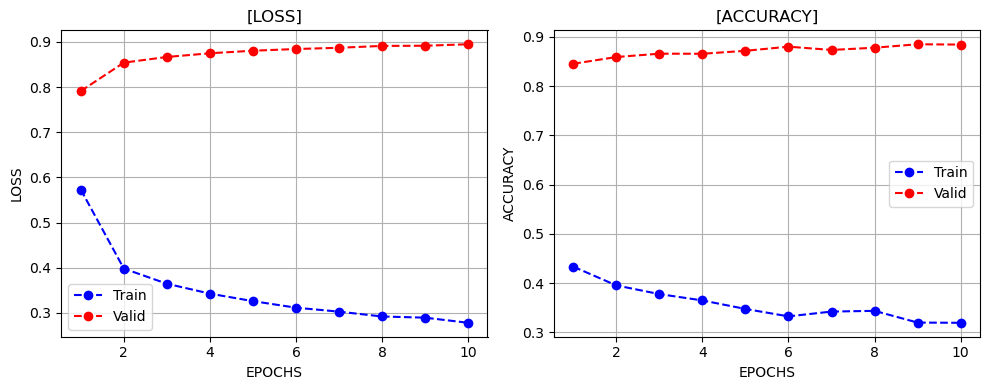

In [ ]:
HIST ={'Train':[], 'Valid':[]}   
# 에포크 단위 학습/검증 진행 
for epoch in range(EPOCHS):
    a = time.time()
    trainLoss, trainAcc = training()
    validLoss, validAcc = evaluate()

    HIST['Train'].append((trainLoss, trainAcc))
    HIST['Valid'].append((validLoss, validAcc))

    print(f'\nEPOCH[{epoch}/{EPOCHS}]----------------')
    print(f'- TRAIN_LOSS {trainLoss:.5f}    ACC {trainAcc:.5f}')
    print(f'- VALID_LOSS {validLoss:.5f}    ACC {validAcc:.5f}')
    
    print(time.time()-a)
print(time.strftime("%H:%M:%S"))